In [29]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import MemorySaver

In [30]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [31]:
model= ChatOpenAI()
def chat_node(state: ChatState):

    # take user query from state
    messages = state['messages']

    # send to model
    response = model.invoke(messages)

    # response store state
    return {'messages': [response]}

In [36]:
checkpointer = MemorySaver()
graph = StateGraph(ChatState)

# add nodes
graph.add_node('chat_node', chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

workflow = graph.compile(checkpointer= checkpointer)

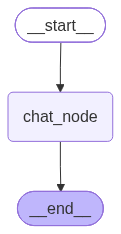

In [33]:
workflow

In [34]:
initial_state = {
    'messages': [HumanMessage(content='Why does Assam face the flood issue every year, is there any permanent solution? How should the government approch this issue ?')]
}

workflow.invoke(initial_state)['messages'][-1].content

'Assam faces the flood issue every year due to its geographical location and the presence of the Brahmaputra River and its tributaries. The state is prone to heavy rainfall during the monsoon season, which causes the rivers to swell and overflow, leading to widespread flooding. \n\nOne of the main causes of the recurring floods in Assam is the lack of proper infrastructure such as embankments, flood control measures, and proper drainage systems. Deforestation, encroachment of wetlands, and climate change are also contributing factors to the flood problem in the region.\n\nTo address this issue and find a permanent solution, the government should take a multi-pronged approach. This could include:\n\n1. Investing in proper flood control infrastructure such as embankments, reservoirs, and drainage systems.\n2. Implementing watershed management practices to reduce soil erosion and increase water retention capacity.\n3. Encouraging afforestation and protecting wetlands to reduce the impact 

In [37]:
thread_id = '1'


while True:
    user_message = input("Ask your question")
    print(f"User: {user_message}")
    if user_message.strip().lower() in ['break', 'quit', 'bye']:
        break
    config = {'configurable': {'thread_id': thread_id}}
    response= workflow.invoke({'messages': [HumanMessage(content= user_message)]}, config= config)

    print(f"AI: {response['messages'][-1].content}")

User: Hi , my name is JAY
AI: Hi Jay! How can I assist you today?
User: What is my name?
AI: Your name is Jay.
User: thanks, bye
AI: You're welcome! If you have any more questions in the future, feel free to ask. Goodbye!
User: bye


In [38]:
workflow.get_state(config= config)

StateSnapshot(values={'messages': [HumanMessage(content='Hi , my name is JAY', additional_kwargs={}, response_metadata={}, id='7fe4de57-5919-40a8-aca2-b3b0ddbe8971'), AIMessage(content='Hi Jay! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 14, 'total_tokens': 24, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-EEg0TcmDSCDLoo3ABCbZiDKFSMKZF', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--01a01b70-cfb7-7a32-abd3-f7d118e338ce-0', usage_metadata={'input_tokens': 14, 'output_tokens': 10, 'total_tokens': 24, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}), HumanMessage